# 3. Exploratory Data Analysis

Generates the EDA plots and saves them to `figures/`. Run after `01_clean_data.ipynb`.

In [1]:
from pathlib import Path

def find_project_root(marker="requirements.txt", max_search_depth=4):
    """Locates the housing_project root so paths work no matter where
    Jupyter was launched from. Two strategies, tried in order:
    1. Walk UPWARD from the current directory (covers launching Jupyter
       from inside the project, e.g. from notebooks/pipeline/).
    2. Search DOWNWARD into subfolders (covers the common case of
       launching Jupyter from your home folder or Desktop, then browsing
       into the project through the Jupyter file browser -- the kernel's
       working directory stays at the launch folder, not the notebook's).
    """
    start = Path.cwd().resolve()

    # Strategy 1: search upward
    for parent in [start] + list(start.parents):
        if (parent / marker).exists():
            return parent

    # Strategy 2: search downward (breadth-first, limited depth)
    frontier = [start]
    for _ in range(max_search_depth):
        next_frontier = []
        for folder in frontier:
            try:
                subdirs = [d for d in folder.iterdir() if d.is_dir() and not d.name.startswith(".")]
            except PermissionError:
                continue
            for d in subdirs:
                if (d / marker).exists():
                    return d
                next_frontier.append(d)
        frontier = next_frontier
        if not frontier:
            break

    raise FileNotFoundError(
        f"Could not locate the project root (looking for '{marker}') starting from {start}.\n"
        f"Fix: either launch Jupyter from inside the housing_project folder, "
        f"or set PROJECT_ROOT manually below, e.g.:\n"
        f'    PROJECT_ROOT = Path(r"C:\\path\\to\\housing_project")'
    )

PROJECT_ROOT = find_project_root()
print(f"Project root: {PROJECT_ROOT}")

Project root: D:\Projectsinterns\housing_project


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
CLEAN_PATH = PROJECT_ROOT / "data" / "housing_clean.csv"
FIG_DIR = PROJECT_ROOT / "figures"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(CLEAN_PATH)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


## Histograms of all numeric columns

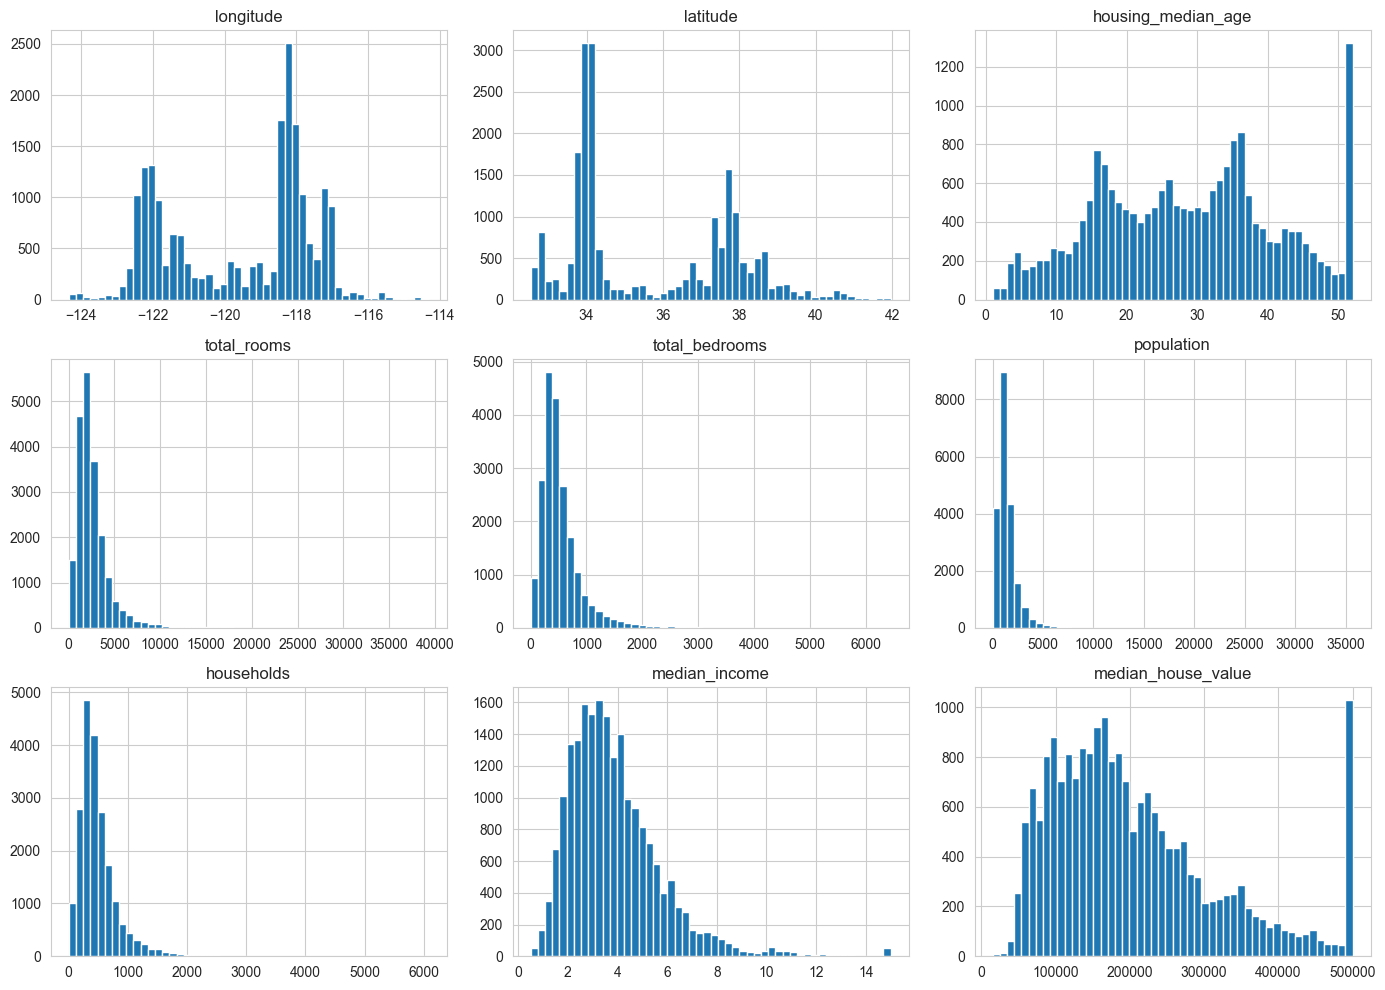

In [3]:
df.hist(bins=50, figsize=(14, 10))
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_histograms.png", dpi=120)
plt.show()

## Geographic scatter: house value by location

The single most illustrative plot for this dataset — reproduces the shape of California and shows the coastal price premium clearly.

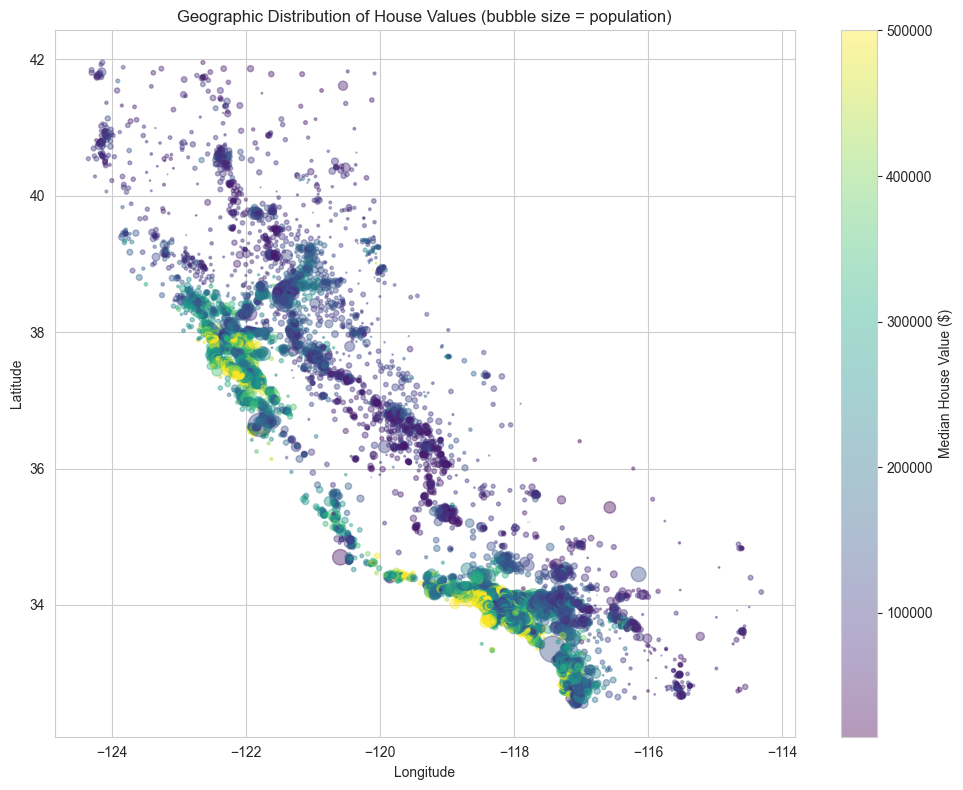

In [4]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df["longitude"], df["latitude"],
    c=df["median_house_value"], cmap="viridis",
    alpha=0.4, s=df["population"] / 100
)
plt.colorbar(sc, label="Median House Value ($)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of House Values (bubble size = population)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_geo_scatter.png", dpi=120)
plt.show()

## Correlation heatmap

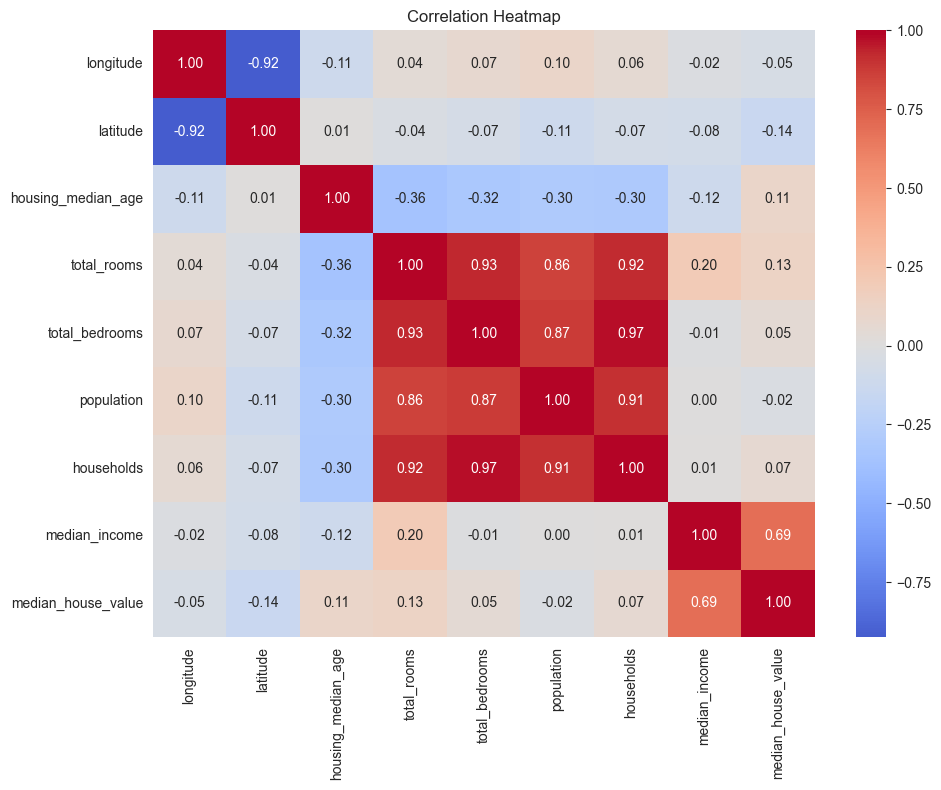

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049580
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [5]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_correlation_heatmap.png", dpi=120)
plt.show()

corr["median_house_value"].sort_values(ascending=False)

## House value by ocean proximity

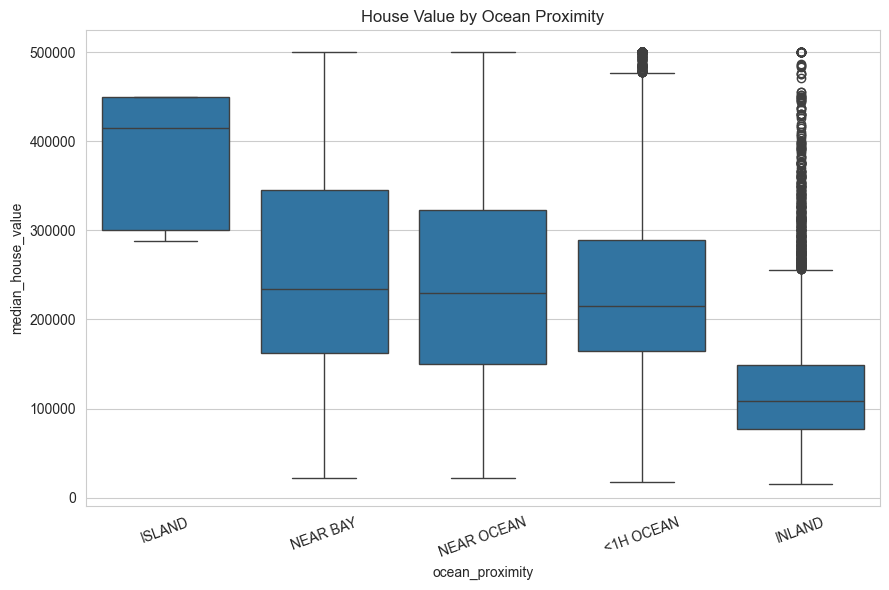

In [6]:
plt.figure(figsize=(9, 6))
order = df.groupby("ocean_proximity")["median_house_value"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", order=order)
plt.title("House Value by Ocean Proximity")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_boxplot_ocean_proximity.png", dpi=120)
plt.show()

## Median income vs house value

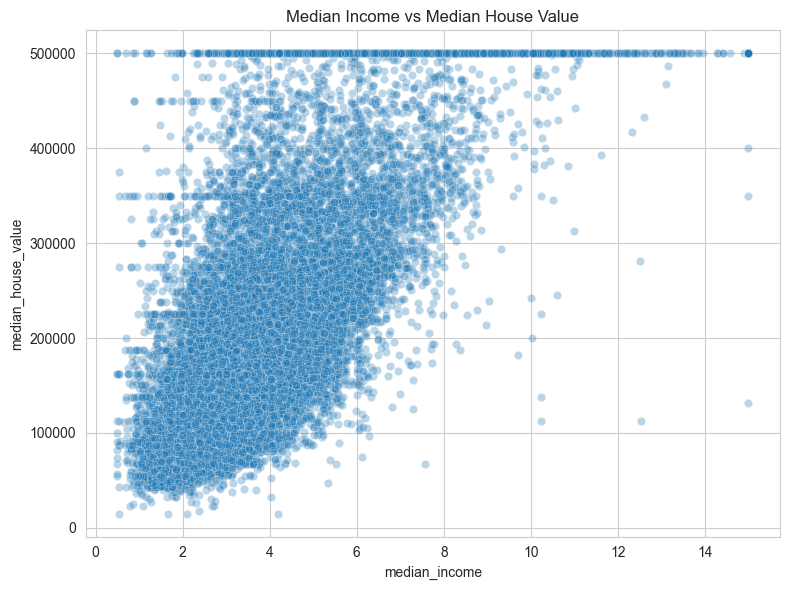

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="median_income", y="median_house_value", alpha=0.3)
plt.title("Median Income vs Median House Value")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_income_vs_value.png", dpi=120)
plt.show()

**Key insight:** `median_income` is by far the strongest predictor of house value (correlation ~0.69). Geography and ocean proximity add meaningful secondary signal.